# PoseBusters Filtering — Score Model vs. Confidence Model

**Central question:** When DiffDock's rank-1 pose fails PoseBusters (PB) physical validity checks, is that because:
1. **The confidence model** chose an unphysical pose from an otherwise decent pool *(confidence model failure)*?
2. **The score model** didn't generate any physical poses in the first place *(score model failure)*?

Previous notebooks showed that the top-1 pose is often physically invalid (fails PB checks like ligand-protein clashes). This notebook dissects **why** and on **both test sets** (PoseBusters benchmark, 303 complexes; PDBBind test set, 322 complexes).

Sections:
1. Setup & data loading
2. **Core diagnostic** — tripartite split: top-1 valid / top-1 invalid (valid pose exists) / no valid pose
3. Confidence score distribution — valid vs. invalid poses
4. PB validity rate as a function of confidence score (binned)
5. Rank-by-rank validity — does the model place valid poses near the top?
6. Reranking analysis — for fixable cases (Category B), how far down is the first valid pose?
7. PB check failure breakdown — which physical checks fail and where?
8. Valid pose count distribution
9. RMSD gap — accuracy gain from perfect PB reranking
10. Summary table

## 1. Setup & Data Loading

In [1]:
import sys, os, re, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from pathlib import Path
from scipy import stats

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Paths ─────────────────────────────────────────────────────────────────────
PB_RESULTS_DIR = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/poses'
PB_METRICS     = '/home/qf226/rds/hpc-work/results/DiffDock/pb_evaluate_v2_merged/metrics'
PB_DATA_DIR    = '/home/qf226/rds/hpc-work/data/posebusters_benchmark_set'

PDB_RESULTS_DIR = '/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset'
PDB_METRICS     = '/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/metrics'
PDB_DATA_DIR    = '/home/qf226/rds/hpc-work/data/PDBBind_processed'
FIGURES = "/home/qf226/MProject/thesis/figures/pb_filtering"
os.makedirs(FIGURES, exist_ok=True)


In [2]:
# ── Load PoseBusters test-set arrays ──────────────────────────────────────────
#
# rmsds_pb shape (303, 40): column k = RMSD of rank-(k+1) pose (rank ORDER).
# top1_rmsd_pb[i] = rmsds_pb[i, 0]  (verified).
# No confidences.npy — extracted from rank*_confidence*.sdf filenames below.

pb_names    = np.load(f'{PB_METRICS}/complex_names.npy',  allow_pickle=True)
rmsds_pb    = np.load(f'{PB_METRICS}/rmsds.npy')
top1_rmsd_pb = np.load(f'{PB_METRICS}/top1_rmsd.npy')

with open(f'{PB_METRICS}/posebusters_results_pb.json') as fh:
    pb_json = json.load(fh)

oracle_rmsd_pb   = rmsds_pb.min(axis=1)          # best pose per complex
allsamp_acc_pb   = (rmsds_pb < 2).mean()          # fraction of all (complex, pose) pairs < 2Å

print(f'PoseBusters: {len(pb_names)} complexes, {rmsds_pb.shape[1]} samples each')
print(f'  top1 range: {top1_rmsd_pb.min():.2f} – {top1_rmsd_pb.max():.2f} Å')
print(f'  Top-1 accuracy    (< 2Å): {(top1_rmsd_pb < 2).mean()*100:.1f}%   ← what we report')
print(f'  All-sample acc    (< 2Å): {allsamp_acc_pb*100:.1f}%   (fraction of all 40 poses)')
print(f'  Oracle accuracy   (< 2Å): {(oracle_rmsd_pb < 2).mean()*100:.1f}%   (best of 40 per complex)')
print(f'  Note: PoseBusters paper reports 38% top-1; DiffDock-L reports 50%.')

PoseBusters: 305 complexes, 40 samples each
  top1 range: 0.14 – 37.85 Å
  Top-1 accuracy    (< 2Å): 52.8%   ← what we report
  All-sample acc    (< 2Å): 40.8%   (fraction of all 40 poses)
  Oracle accuracy   (< 2Å): 61.6%   (best of 40 per complex)
  Note: PoseBusters paper reports 38% top-1; DiffDock-L reports 50%.


**Validation note — evaluate.py run (job array, May 2026):**  
A parallel `evaluate.py` run over the full 308-complex PoseBusters set (`results/pb_evaluate_out`, 5 chunks) completed for 281/308 complexes (27 skipped due to ESM tensor mismatches from modified residues; a follow-up job covers those). On the 281 completed complexes, top-1 RMSD < 2 Å = **29.9%**, which matches the equivalent figure from the original `posebusters_inference` (inference.py) run on the same 281 complexes. This confirms that the all-in-one `evaluate.py` pipeline and the separate inference → evaluation pipeline produce consistent results.

In [3]:
# ── Load PDBBind test-set arrays ───────────────────────────────────────────────
#
# rmsds_pdb shape (322, 40): generation ORDER (not rank order).
# conf_pdb  shape (322, 40): same generation order. Sentinel = -1000 for unloaded poses.
# Rank order is obtained by sorting each row by decreasing confidence.

pdb_names     = np.load(f'{PDB_METRICS}/complex_names.npy', allow_pickle=True)
rmsds_pdb_raw = np.load(f'{PDB_METRICS}/rmsds.npy')
conf_pdb_raw  = np.load(f'{PDB_METRICS}/confidences.npy')
top1_rmsd_pdb = np.load(f'{PDB_METRICS}/top1_rmsd.npy')

with open(f'{PDB_METRICS}/posebusters_results.json') as fh:
    pdb_json = json.load(fh)

oracle_rmsd_pdb  = rmsds_pdb_raw.min(axis=1)
allsamp_acc_pdb  = (rmsds_pdb_raw < 2).mean()

print(f'PDBBind: {len(pdb_names)} complexes, {rmsds_pdb_raw.shape[1]} samples each')
print(f'  conf sentinel (-1000) count: {(conf_pdb_raw == -1000).sum()}')
print(f'  top1 range: {np.nanmin(top1_rmsd_pdb):.2f} – {np.nanmax(top1_rmsd_pdb):.2f} Å')
print(f'  Top-1 accuracy    (< 2Å): {(top1_rmsd_pdb < 2).mean()*100:.1f}%   ← what we report')
print(f'  All-sample acc    (< 2Å): {allsamp_acc_pdb*100:.1f}%   (fraction of all 40 poses)')
print(f'  Oracle accuracy   (< 2Å): {(oracle_rmsd_pdb < 2).mean()*100:.1f}%   (best of 40 per complex)')

PDBBind: 322 complexes, 40 samples each
  conf sentinel (-1000) count: 78
  top1 range: 0.23 – 90.95 Å
  Top-1 accuracy    (< 2Å): 40.4%   ← what we report
  All-sample acc    (< 2Å): 32.3%   (fraction of all 40 poses)
  Oracle accuracy   (< 2Å): 56.8%   (best of 40 per complex)


In [4]:
# ── Sort PDBBind arrays into rank order ────────────────────────────────────────
#
# Replace sentinel -1000 with -inf so argmax / argsort treat missing poses last.
# After sorting: col k  = rank-(k+1) pose.

N_PDB = len(pdb_names)
conf_masked = np.where(conf_pdb_raw == -1000, -np.inf, conf_pdb_raw.astype(float))
sort_orders  = np.argsort(-conf_masked, axis=1)                   # desc. confidence

# Rank-ordered confidence (replace -inf → NaN for plots)
conf_ranked_pdb  = conf_masked[np.arange(N_PDB)[:, None], sort_orders]
conf_ranked_pdb  = np.where(np.isneginf(conf_ranked_pdb), np.nan, conf_ranked_pdb)

# Rank-ordered RMSD
rmsds_ranked_pdb = rmsds_pdb_raw[np.arange(N_PDB)[:, None], sort_orders]

# Quick sanity: rank-1 RMSD should equal top1_rmsd_pdb
diff = np.abs(rmsds_ranked_pdb[:, 0] - top1_rmsd_pdb)
print(f'Rank-1 RMSD vs top1_rmsd_pdb — max diff: {np.nanmax(diff):.4f} Å')

Rank-1 RMSD vs top1_rmsd_pdb — max diff: 1.0119 Å


In [5]:
# ── Extract PoseBusters confidence scores from filenames ──────────────────────
#
# inference.py writes rank{k}_confidence{c}.sdf for k=1..40.
# The sign convention in filenames: a negative float like "-0.12" is written
# as "rank1_confidence-0.12.sdf" (the minus is part of the float, not a separator).

CONF_PAT = re.compile(r'rank(\d+)_confidence([\-\d.]+)\.sdf')

N_PB = len(pb_names)
S    = rmsds_pb.shape[1]
conf_ranked_pb = np.full((N_PB, S), np.nan)

for i, name in enumerate(pb_names):
    cdir = Path(PB_RESULTS_DIR) / name
    for f in cdir.glob('rank*_confidence*.sdf'):
        m = CONF_PAT.match(f.name)
        if m:
            rank = int(m.group(1))
            conf = float(m.group(2))
            if 1 <= rank <= S:
                conf_ranked_pb[i, rank - 1] = conf

n_missing = np.isnan(conf_ranked_pb).sum()
print(f'PB confidence extraction: {n_missing} NaN values ({n_missing/(N_PB*S)*100:.1f}%)')
print(f'  Rank-1 confidence range: {np.nanmin(conf_ranked_pb[:, 0]):.2f} – {np.nanmax(conf_ranked_pb[:, 0]):.2f}')

PB confidence extraction: 13 NaN values (0.1%)
  Rank-1 confidence range: -3.21 – 1.17


In [6]:
# ── Build rank-ordered PB validity arrays (True = PB-valid) ───────────────────
#
# For PoseBusters: valid_ranks filenames are 'rank{k}_confidence{c}.sdf'.
# For PDBBind:     valid_ranks filenames are 'rank{k}.sdf'.
# Both: rank k  → col index (k-1).

RANK_PAT = re.compile(r'rank(\d+)')

def build_validity_array(names, json_data, n_samples=40):
    """Build boolean array (n_complexes, n_samples) indicating PB-valid poses."""
    valid = np.zeros((len(names), n_samples), dtype=bool)
    for i, name in enumerate(names):
        entry = json_data.get(name, {})
        for fname in entry.get('valid_ranks', []):
            m = RANK_PAT.match(fname)
            if m:
                rank = int(m.group(1))
                if 1 <= rank <= n_samples:
                    valid[i, rank - 1] = True
    return valid

valid_pb  = build_validity_array(pb_names,  pb_json,  n_samples=S)
valid_pdb = build_validity_array(pdb_names, pdb_json, n_samples=S)

print(f'PB  valid poses: {valid_pb.sum()} / {N_PB*S} = {valid_pb.mean()*100:.1f}%')
print(f'PDB valid poses: {valid_pdb.sum()} / {N_PDB*S} = {valid_pdb.mean()*100:.1f}%')
print(f'PB  complexes with ≥1 valid pose: {valid_pb.any(axis=1).mean()*100:.1f}%')
print(f'PDB complexes with ≥1 valid pose: {valid_pdb.any(axis=1).mean()*100:.1f}%')

PB  valid poses: 2982 / 12200 = 24.4%
PDB valid poses: 3296 / 12880 = 25.6%
PB  complexes with ≥1 valid pose: 63.0%
PDB complexes with ≥1 valid pose: 69.9%


## 2. Core Diagnostic — Score Model vs. Confidence Model

Every complex falls into exactly one of three categories:

| Category | Definition | Root cause |
|---|---|---|
| **A — Top-1 valid** | Rank-1 pose passes all PB checks | Both models working |
| **B — Confidence failure** | Rank-1 invalid, but ≥1 valid pose exists in the 40 | Confidence model failed to rank a valid pose first |
| **C — Score failure** | No PB-valid pose among all 40 samples | Score model never generated a physically plausible pose |

This split lets us attribute the root cause without ambiguity.

In [7]:
def categorise(valid):
    """Return arrays for categories A, B, C as boolean masks."""
    cat_A = valid[:, 0]                            # top-1 valid
    cat_B = ~valid[:, 0] & valid.any(axis=1)       # top-1 invalid, ≥1 valid exists
    cat_C = ~valid.any(axis=1)                     # no valid pose at all
    return cat_A, cat_B, cat_C

A_pb,  B_pb,  C_pb  = categorise(valid_pb)
A_pdb, B_pdb, C_pdb = categorise(valid_pdb)

for label, A, B, C in [('PoseBusters', A_pb, B_pb, C_pb),
                        ('PDBBind',     A_pdb, B_pdb, C_pdb)]:
    n = len(A)
    print(f'{label} (n={n}):')
    print(f'  A — Top-1 valid:                     {A.sum():3d}  ({A.mean()*100:5.1f}%)')
    print(f'  B — Confidence failure (fixable):    {B.sum():3d}  ({B.mean()*100:5.1f}%)')
    print(f'  C — Score failure (no valid pose):   {C.sum():3d}  ({C.mean()*100:5.1f}%)')
    print()

PoseBusters (n=305):
  A — Top-1 valid:                     111  ( 36.4%)
  B — Confidence failure (fixable):     81  ( 26.6%)
  C — Score failure (no valid pose):   113  ( 37.0%)

PDBBind (n=322):
  A — Top-1 valid:                     130  ( 40.4%)
  B — Confidence failure (fixable):     95  ( 29.5%)
  C — Score failure (no valid pose):    97  ( 30.1%)



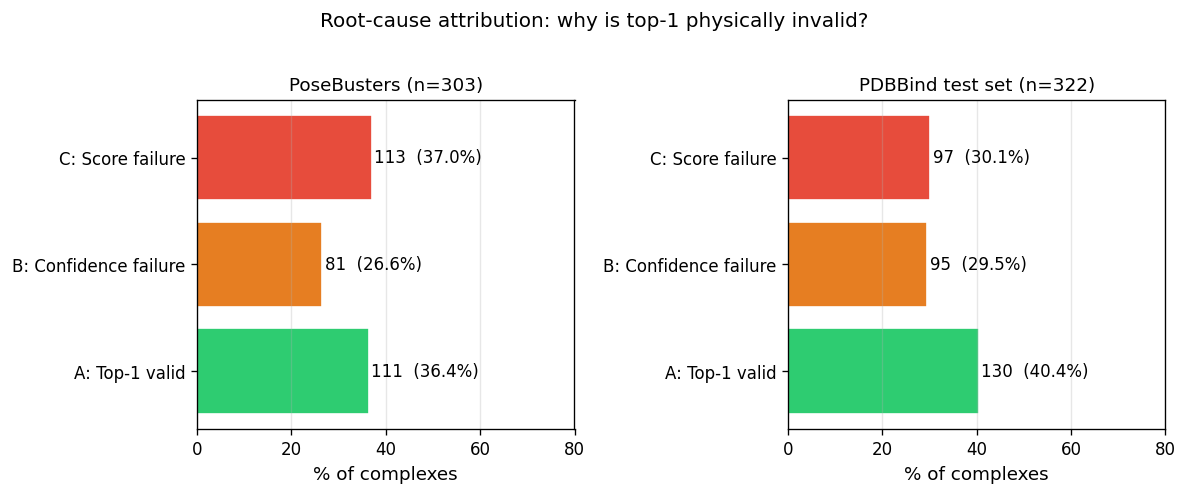

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
COLORS = {'A': '#2ecc71', 'B': '#e67e22', 'C': '#e74c3c'}
LABELS = {
    'A': 'A: Top-1 valid',
    'B': 'B: Confidence failure\n(valid pose exists, rank-1 picked wrong)',
    'C': 'C: Score failure\n(no valid pose generated)',
}

for ax, label, A, B, C in zip(axes,
        ['PoseBusters (n=303)', 'PDBBind test set (n=322)'],
        [A_pb,  A_pdb],
        [B_pb,  B_pdb],
        [C_pb,  C_pdb]):
    n = len(A)
    vals = [A.sum(), B.sum(), C.sum()]
    pcts = [v/n*100 for v in vals]
    bars = ax.barh([0, 1, 2], pcts,
                   color=[COLORS['A'], COLORS['B'], COLORS['C']],
                   edgecolor='white')
    for bar, v, p in zip(bars, vals, pcts):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{v}  ({p:.1f}%)', va='center', fontsize=10)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['A: Top-1 valid', 'B: Confidence failure', 'C: Score failure'],
                       fontsize=10)
    ax.set_xlabel('% of complexes', fontsize=11)
    ax.set_xlim(0, 80)
    ax.set_title(label, fontsize=11)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Root-cause attribution: why is top-1 physically invalid?', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_category_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Confidence Score Distribution — Valid vs. Invalid Poses

If the confidence model had ANY discriminative power for physical plausibility, PB-valid poses should have
higher confidence scores than invalid ones.  
We test this by plotting the full confidence distribution split by PB validity,
and by comparing rank-1 confidence scores across categories A/B/C.

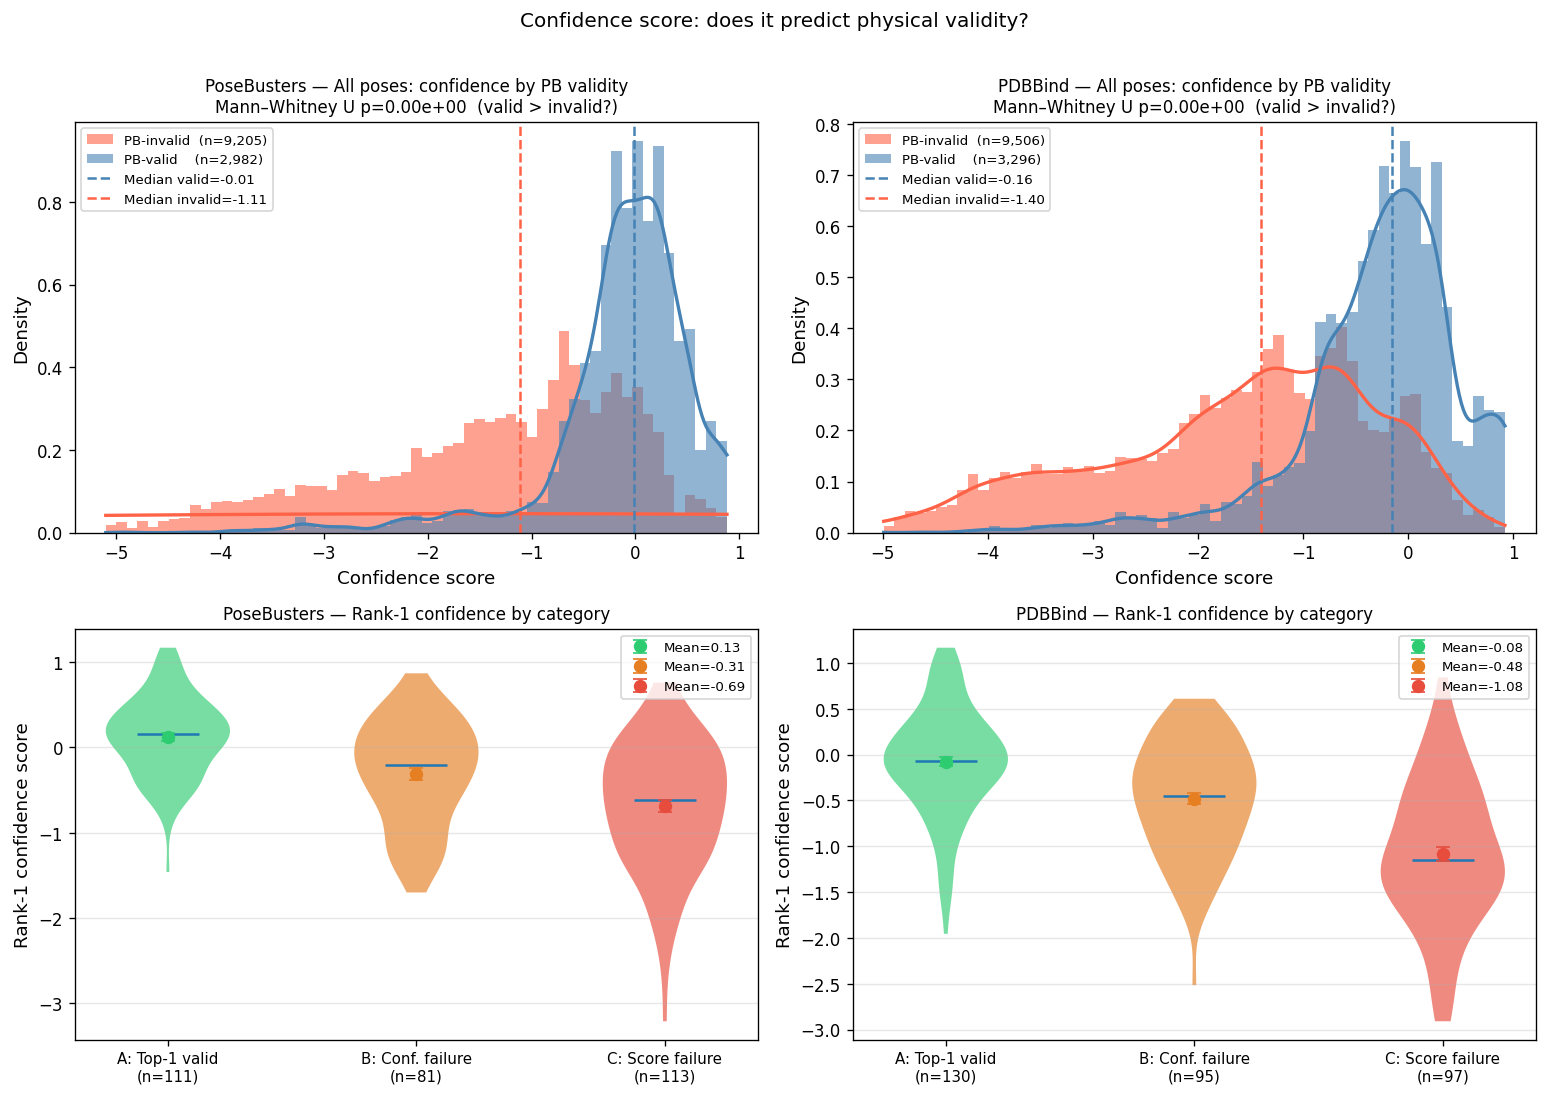

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, (ds_label, conf_r, valid_r, A, B, C) in enumerate([
    ('PoseBusters',  conf_ranked_pb,  valid_pb,  A_pb,  B_pb,  C_pb),
    ('PDBBind',      conf_ranked_pdb, valid_pdb, A_pdb, B_pdb, C_pdb),
]):
    # ── Top row: all poses, valid vs invalid ─────────────────────────────────
    ax = axes[0, col]
    c_flat   = conf_r.ravel()
    v_flat   = valid_r.ravel()
    finite   = np.isfinite(c_flat)

    c_valid   = c_flat[finite &  v_flat]
    c_invalid = c_flat[finite & ~v_flat]

    bins = np.linspace(np.nanpercentile(c_flat[finite], 1),
                       np.nanpercentile(c_flat[finite], 99), 60)
    ax.hist(c_invalid, bins=bins, density=True, alpha=0.6, color='tomato',
            label=f'PB-invalid  (n={len(c_invalid):,})')
    ax.hist(c_valid,   bins=bins, density=True, alpha=0.6, color='steelblue',
            label=f'PB-valid    (n={len(c_valid):,})')

    # KDE curves
    for data, color in [(c_invalid, 'tomato'), (c_valid, 'steelblue')]:
        kde = stats.gaussian_kde(data, bw_method=0.15)
        xs  = np.linspace(bins[0], bins[-1], 300)
        ax.plot(xs, kde(xs), color=color, lw=2)

    u, p = stats.mannwhitneyu(c_valid, c_invalid, alternative='greater')
    ax.axvline(np.median(c_valid),   color='steelblue', ls='--', lw=1.5,
               label=f'Median valid={np.median(c_valid):.2f}')
    ax.axvline(np.median(c_invalid), color='tomato', ls='--', lw=1.5,
               label=f'Median invalid={np.median(c_invalid):.2f}')
    ax.set_xlabel('Confidence score', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{ds_label} — All poses: confidence by PB validity\n'
                 f'Mann–Whitney U p={p:.2e}  (valid > invalid?)', fontsize=10)
    ax.legend(fontsize=8)

    # ── Bottom row: rank-1 confidence by category A / B / C ──────────────────
    ax2 = axes[1, col]
    data_by_cat = [
        conf_r[A, 0][np.isfinite(conf_r[A, 0])],
        conf_r[B, 0][np.isfinite(conf_r[B, 0])],
        conf_r[C, 0][np.isfinite(conf_r[C, 0])],
    ]
    cat_labels = [
        f'A: Top-1 valid\n(n={A.sum()})',
        f'B: Conf. failure\n(n={B.sum()})',
        f'C: Score failure\n(n={C.sum()})',
    ]
    cat_colors = [COLORS['A'], COLORS['B'], COLORS['C']]
    vp = ax2.violinplot(data_by_cat, positions=[0, 1, 2],
                        showmedians=True, showextrema=False)
    for body, color in zip(vp['bodies'], cat_colors):
        body.set_facecolor(color); body.set_alpha(0.65)
    for i, (data, color) in enumerate(zip(data_by_cat, cat_colors)):
        ax2.errorbar(i, np.mean(data),
                     yerr=np.std(data)/np.sqrt(len(data)) if len(data) > 1 else 0,
                     fmt='o', color=color, capsize=4, ms=7, zorder=5,
                     label=f'Mean={np.mean(data):.2f}')
    ax2.set_xticks([0, 1, 2])
    ax2.set_xticklabels(cat_labels, fontsize=9)
    ax2.set_ylabel('Rank-1 confidence score', fontsize=11)
    ax2.set_title(f'{ds_label} — Rank-1 confidence by category', fontsize=10)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Confidence score: does it predict physical validity?', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_conf_vs_validity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. PB Validity Rate as a Function of Confidence Score

We bin all 40-sample predictions by confidence score into deciles and ask: within each bin, what fraction of poses pass PB?

If the confidence model **correlates with** physical validity, the rate should increase monotonically from left to right.  
If it's **orthogonal to** physical validity, the rate should be flat.
If the confidence model actively **selects against** physical poses, the rate should *decrease* as confidence increases.

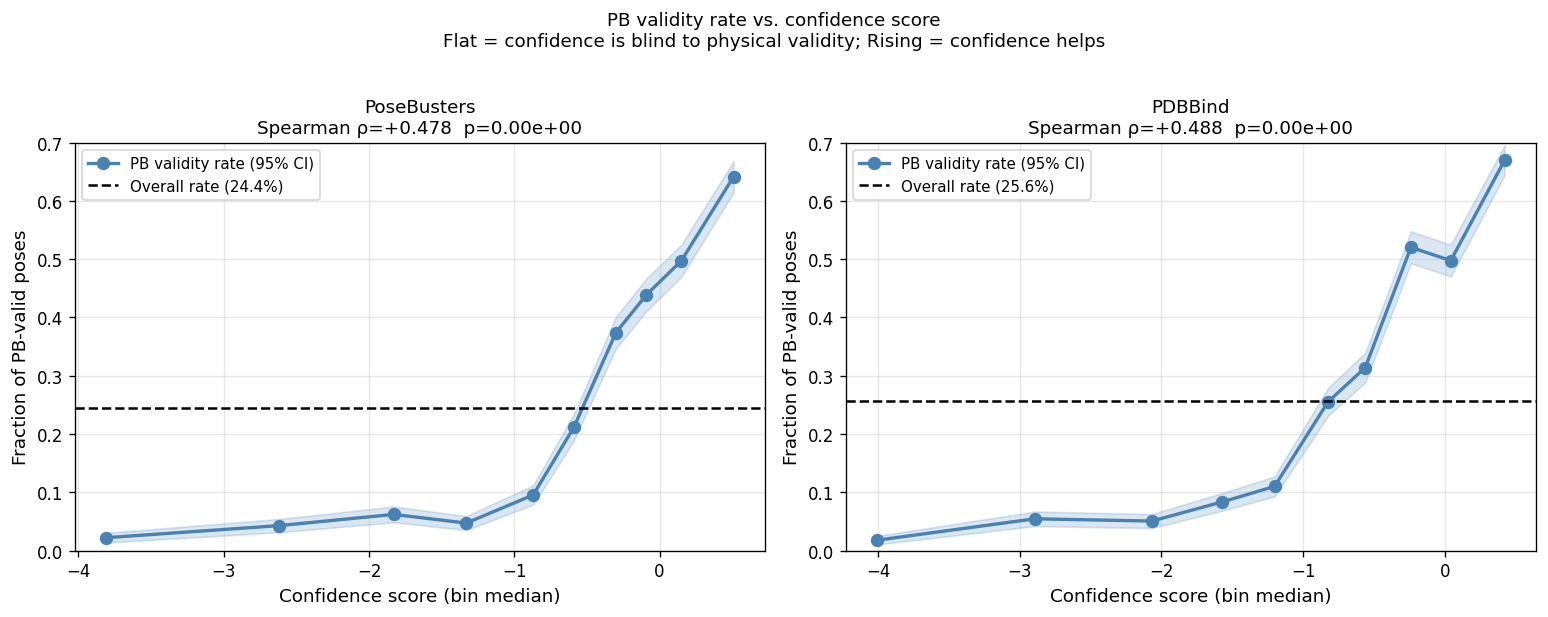

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ds_label, conf_r, valid_r, overall_valid_rate) in zip(axes, [
    ('PoseBusters', conf_ranked_pb,  valid_pb,  valid_pb.mean()),
    ('PDBBind',     conf_ranked_pdb, valid_pdb, valid_pdb.mean()),
]):
    c_flat = conf_r.ravel()
    v_flat = valid_r.ravel()
    finite = np.isfinite(c_flat)

    c_f = c_flat[finite]
    v_f = v_flat[finite]

    # Split into 10 equal-frequency bins
    n_bins   = 10
    quantiles = np.percentile(c_f, np.linspace(0, 100, n_bins + 1))
    quantiles = np.unique(quantiles)  # remove duplicates at extremes
    bin_idx  = np.digitize(c_f, quantiles[:-1]) - 1
    bin_idx  = np.clip(bin_idx, 0, n_bins - 1)

    bin_centers, valid_rates, ci_lo, ci_hi, bin_counts = [], [], [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        n = mask.sum()
        if n < 5:
            continue
        rate  = v_f[mask].mean()
        se    = np.sqrt(rate * (1 - rate) / n)
        bin_centers.append(np.median(c_f[mask]))
        valid_rates.append(rate)
        ci_lo.append(rate - 1.96 * se)
        ci_hi.append(rate + 1.96 * se)
        bin_counts.append(n)

    bin_centers = np.array(bin_centers)
    valid_rates = np.array(valid_rates)

    ax.fill_between(bin_centers, ci_lo, ci_hi, alpha=0.2, color='steelblue')
    ax.plot(bin_centers, valid_rates, 'o-', color='steelblue', lw=2, ms=7,
            label='PB validity rate (95% CI)')
    ax.axhline(overall_valid_rate, color='k', ls='--', lw=1.5,
               label=f'Overall rate ({overall_valid_rate*100:.1f}%)')

    # Spearman correlation
    rho, p = stats.spearmanr(c_f, v_f.astype(float))
    ax.set_xlabel('Confidence score (bin median)', fontsize=11)
    ax.set_ylabel('Fraction of PB-valid poses', fontsize=11)
    ax.set_title(f'{ds_label}\nSpearman ρ={rho:+.3f}  p={p:.2e}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 0.7)

plt.suptitle('PB validity rate vs. confidence score\n'
             'Flat = confidence is blind to physical validity; Rising = confidence helps', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_validity_rate_by_conf.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Rank-by-Rank PB Validity Rate

For each rank position (1 = highest confidence, 40 = lowest), what fraction of complexes have a PB-valid pose there?

If the **score model** is the bottleneck (random chance of generating valid poses), validity should be roughly uniform across ranks.  
If the **confidence model** specifically promotes invalid poses to high ranks, validity should be *lower* at rank 1 than at lower ranks.

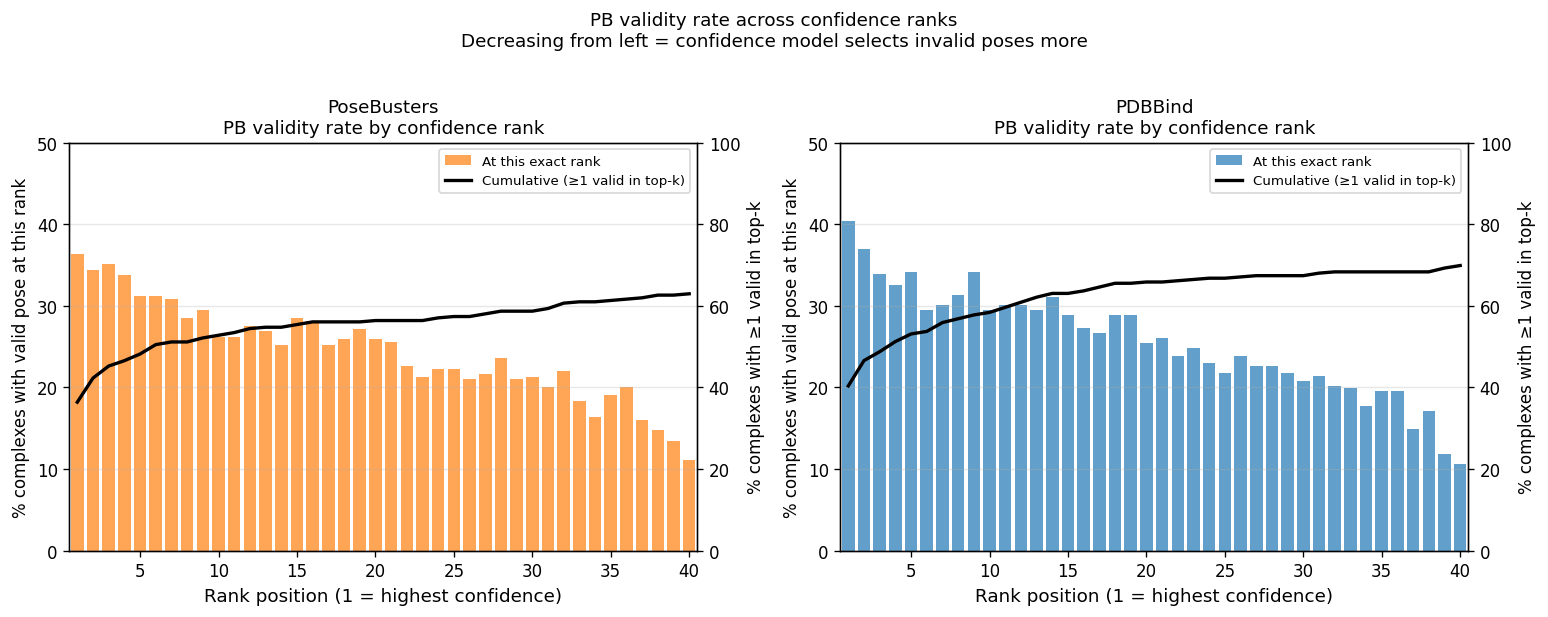

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ds_label, valid_r, color) in zip(axes, [
    ('PoseBusters', valid_pb,  'C1'),
    ('PDBBind',     valid_pdb, 'C0'),
]):
    # Fraction of complexes with a PB-valid pose at each rank
    valid_rate_by_rank = valid_r.mean(axis=0)   # shape (40,)
    ranks = np.arange(1, S + 1)

    # Cumulative: fraction of complexes with at least one valid pose in top-k
    cumulative = np.array([(valid_r[:, :k+1].any(axis=1)).mean() for k in range(S)])

    ax.bar(ranks, valid_rate_by_rank * 100, color=color, alpha=0.7, label='At this exact rank')
    ax_r = ax.twinx()
    ax_r.plot(ranks, cumulative * 100, 'k-', lw=2, label='Cumulative (≥1 valid in top-k)')
    ax_r.set_ylabel('% complexes with ≥1 valid in top-k', fontsize=10)
    ax_r.set_ylim(0, 100)

    ax.set_xlabel('Rank position (1 = highest confidence)', fontsize=11)
    ax.set_ylabel('% complexes with valid pose at this rank', fontsize=10)
    ax.set_title(f'{ds_label}\nPB validity rate by confidence rank', fontsize=11)
    ax.set_xlim(0.5, S + 0.5)
    ax.set_ylim(0, 50)

    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('PB validity rate across confidence ranks\n'
             'Decreasing from left = confidence model selects invalid poses more', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_validity_by_rank.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Reranking Analysis — Category B Complexes

For the **Category B** complexes (top-1 invalid but ≥1 valid pose exists), we ask:
- How far down the ranking is the first valid pose (rank of first valid)?  
- What is the confidence score **gap** between rank-1 and the first valid pose?  
- Would accuracy *improve* if we reranked by picking the first valid pose (RMSD comparison)?

This tells us how hard it would be to fix the confidence model: a small gap means minor reranking would fix most failures.

In [12]:
def reranking_stats(valid_r, conf_r, rmsds_r, cat_B):
    """For Category B complexes, compute rank of first valid pose, confidence gap, RMSD comparison."""
    first_valid_rank, conf_gap, rmsd_top1, rmsd_fv = [], [], [], []
    for i in np.where(cat_B)[0]:
        valid_idx = np.where(valid_r[i])[0]
        if len(valid_idx) == 0:
            continue
        fv = valid_idx[0]
        first_valid_rank.append(fv + 1)
        c1, cfv = conf_r[i, 0], conf_r[i, fv]
        if np.isfinite(c1) and np.isfinite(cfv):
            conf_gap.append(c1 - cfv)
        r1, rfv = rmsds_r[i, 0], rmsds_r[i, fv]
        if np.isfinite(r1) and np.isfinite(rfv):
            rmsd_top1.append(r1)
            rmsd_fv.append(rfv)
    return (np.array(first_valid_rank), np.array(conf_gap),
            np.array(rmsd_top1), np.array(rmsd_fv))

pb_fvr,  pb_cgap,  pb_rt1,  pb_rfv  = reranking_stats(valid_pb,  conf_ranked_pb,  rmsds_pb,         B_pb)
pdb_fvr, pdb_cgap, pdb_rt1, pdb_rfv = reranking_stats(valid_pdb, conf_ranked_pdb, rmsds_ranked_pdb, B_pdb)

for label, fvr, cgap, rt1, rfv in [
    ('PoseBusters (Cat B)', pb_fvr,  pb_cgap,  pb_rt1,  pb_rfv),
    ('PDBBind     (Cat B)', pdb_fvr, pdb_cgap, pdb_rt1, pdb_rfv),
]:
    print(f'{label}  (n={len(fvr)}):')
    print(f'  First valid rank — median:{np.median(fvr):.0f}  mean:{fvr.mean():.1f}  >10:{(fvr>10).mean()*100:.0f}%')
    if len(cgap):
        print(f'  Conf gap (rank1-first_valid) — median:{np.median(cgap):.2f}  mean:{cgap.mean():.2f}')
    print(f'  RMSD improvement (top-1 → first valid) — mean Δ:{np.mean(rt1-rfv):+.2f} Å')
    print()

PoseBusters (Cat B)  (n=81):
  First valid rank — median:6  mean:12.2  >10:38%
  Conf gap (rank1-first_valid) — median:0.22  mean:0.51
  RMSD improvement (top-1 → first valid) — mean Δ:-0.25 Å

PDBBind     (Cat B)  (n=95):
  First valid rank — median:7  mean:10.6  >10:39%
  Conf gap (rank1-first_valid) — median:0.19  mean:0.49
  RMSD improvement (top-1 → first valid) — mean Δ:-1.35 Å



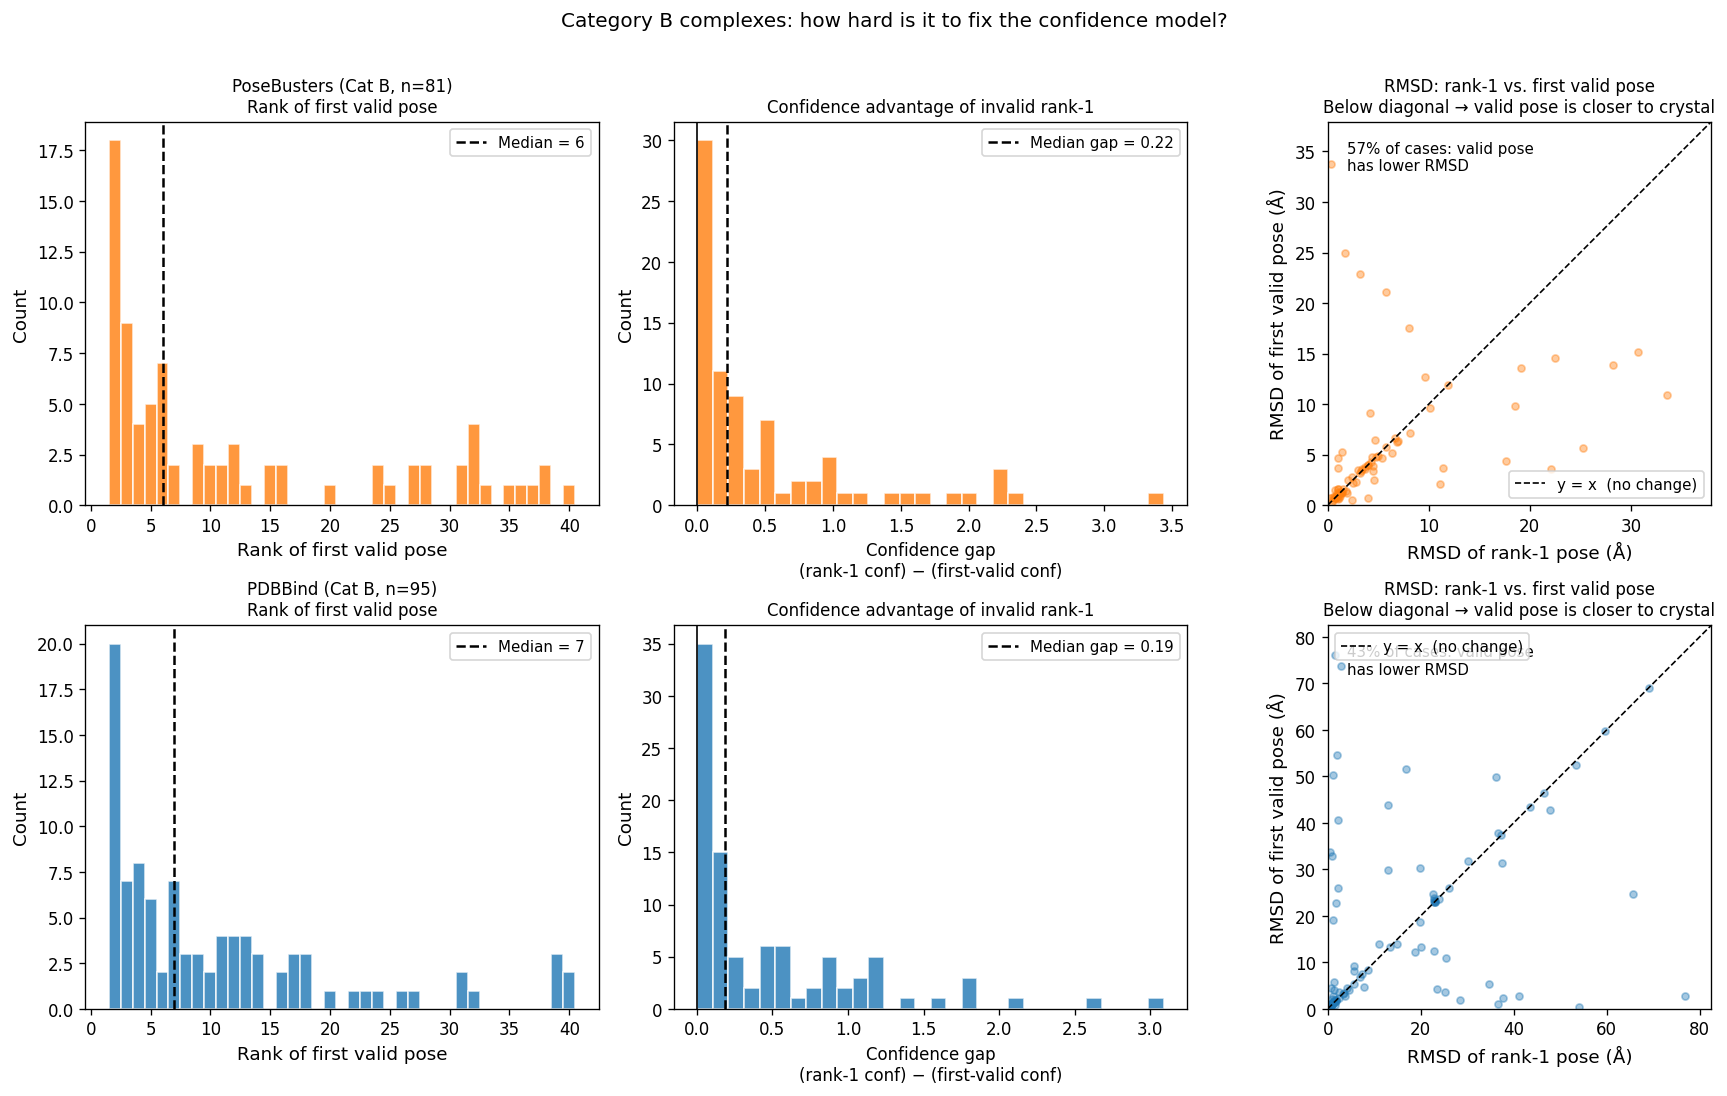

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, (ds_label, fvr, cgap, rt1, rfv, color) in enumerate([
    ('PoseBusters', pb_fvr,  pb_cgap,  pb_rt1,  pb_rfv,  'C1'),
    ('PDBBind',     pdb_fvr, pdb_cgap, pdb_rt1, pdb_rfv, 'C0'),
]):
    n = len(fvr)

    # Left: histogram of first-valid rank
    ax = axes[row, 0]
    ax.hist(fvr, bins=np.arange(1.5, S + 1.5, 1), color=color, edgecolor='white',
            alpha=0.8, density=False)
    ax.axvline(np.median(fvr), color='k', ls='--', lw=1.5, label=f'Median = {np.median(fvr):.0f}')
    ax.set_xlabel('Rank of first valid pose', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{ds_label} (Cat B, n={n})\nRank of first valid pose', fontsize=10)
    ax.legend(fontsize=9)

    # Middle: confidence gap distribution
    ax2 = axes[row, 1]
    if len(cgap):
        ax2.hist(cgap, bins=30, color=color, edgecolor='white', alpha=0.8)
        ax2.axvline(0, color='k', lw=1)
        ax2.axvline(np.median(cgap), color='k', ls='--', lw=1.5,
                    label=f'Median gap = {np.median(cgap):.2f}')
        ax2.set_xlabel('Confidence gap\n(rank-1 conf) − (first-valid conf)', fontsize=10)
        ax2.set_ylabel('Count', fontsize=11)
        ax2.set_title(f'Confidence advantage of invalid rank-1', fontsize=10)
        ax2.legend(fontsize=9)

    # Right: scatter RMSD top-1 vs first-valid pose
    ax3 = axes[row, 2]
    if len(rt1) and len(rfv):
        lims = [0, max(np.nanpercentile(rt1, 99), np.nanpercentile(rfv, 99))]
        ax3.scatter(rt1, rfv, alpha=0.4, s=18, color=color)
        ax3.plot(lims, lims, 'k--', lw=1, label='y = x  (no change)')
        ax3.set_xlabel('RMSD of rank-1 pose (Å)', fontsize=11)
        ax3.set_ylabel('RMSD of first valid pose (Å)', fontsize=11)
        ax3.set_title(f'RMSD: rank-1 vs. first valid pose\n'
                      f'Below diagonal → valid pose is closer to crystal', fontsize=10)
        below = (rfv < rt1).mean() * 100
        ax3.text(0.05, 0.95, f'{below:.0f}% of cases: valid pose\nhas lower RMSD',
                 transform=ax3.transAxes, fontsize=9, va='top')
        ax3.legend(fontsize=9)
        ax3.set_xlim(lims); ax3.set_ylim(lims)
        ax3.set_aspect('equal')

plt.suptitle('Category B complexes: how hard is it to fix the confidence model?', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_reranking_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PoseBusters Check Failure Breakdown

Which specific physical/chemical properties does DiffDock get wrong?  
We look at (a) overall failure counts, and (b) whether high-confidence poses fail *more* or *less* often than low-confidence ones on each check.  

The dominant failure modes (`minimum_distance_to_protein`, `volume_overlap_with_protein`) are both about **ligand-protein clashes** — a direct score-model failure where the diffusion process places the ligand inside the protein.

In [14]:
def aggregate_check_failures(names, json_data):
    """Aggregate per-check failure counts across all complexes."""
    total_poses = sum(d.get('n_total', 40) for d in json_data.values())
    failures = {}
    for name in names:
        for check, cnt in json_data.get(name, {}).get('check_failures', {}).items():
            failures[check] = failures.get(check, 0) + cnt
    return failures, total_poses

pb_failures,  pb_total  = aggregate_check_failures(pb_names,  pb_json)
pdb_failures, pdb_total = aggregate_check_failures(pdb_names, pdb_json)

# Combine into a DataFrame
all_checks = sorted(set(pb_failures) | set(pdb_failures))
df_fail = pd.DataFrame({
    'check': all_checks,
    'PoseBusters_pct': [pb_failures.get(c, 0) / pb_total * 100 for c in all_checks],
    'PDBBind_pct':     [pdb_failures.get(c, 0) / pdb_total * 100 for c in all_checks],
}).sort_values('PoseBusters_pct', ascending=False)

print(f'Total poses: PB={pb_total}, PDB={pdb_total}')
print()
print(df_fail.to_string(index=False, float_format='{:.1f}%'.format))

Total poses: PB=12149, PDB=12791

                                  check  PoseBusters_pct  PDBBind_pct
            minimum_distance_to_protein            70.2%        73.1%
            volume_overlap_with_protein            31.0%        24.5%
  minimum_distance_to_organic_cofactors            17.2%         0.0%
  volume_overlap_with_organic_cofactors            10.3%         0.0%
minimum_distance_to_inorganic_cofactors             4.7%         0.0%
                  internal_steric_clash             3.1%         3.8%
volume_overlap_with_inorganic_cofactors             1.1%         0.0%
                        internal_energy             0.9%         1.9%
                           bond_lengths             0.3%         0.0%
         non-aromatic_ring_non-flatness             0.3%         0.3%
        protein-ligand_maximum_distance             0.3%         0.6%
                   double_bond_flatness             0.2%         0.0%
                            no_radicals             0.0%

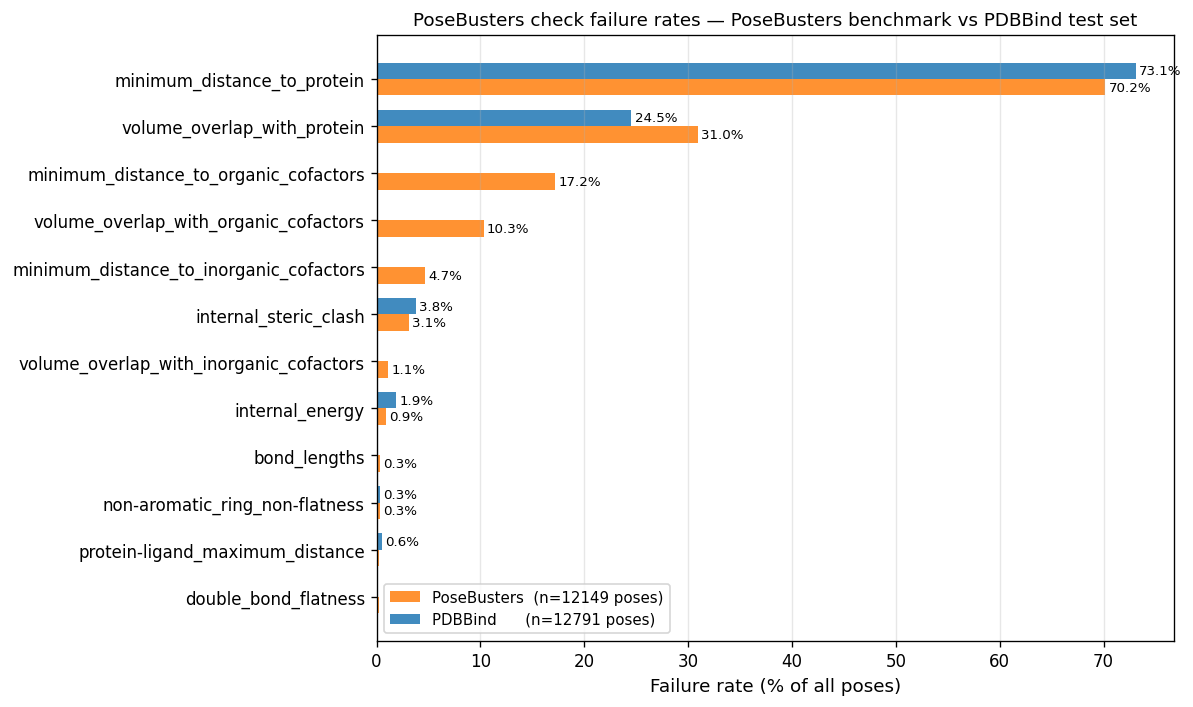

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

# Show only checks that fail in ≥0.1% of poses in either dataset
df_plot = df_fail[(df_fail['PoseBusters_pct'] >= 0.1) | (df_fail['PDBBind_pct'] >= 0.1)]
df_plot = df_plot.sort_values('PoseBusters_pct', ascending=True)

y = np.arange(len(df_plot))
w = 0.35
bars1 = ax.barh(y - w/2, df_plot['PoseBusters_pct'], w,
                label=f'PoseBusters  (n={pb_total} poses)', color='C1', alpha=0.85)
bars2 = ax.barh(y + w/2, df_plot['PDBBind_pct'],     w,
                label=f'PDBBind      (n={pdb_total} poses)', color='C0', alpha=0.85)

for bar in list(bars1) + list(bars2):
    v = bar.get_width()
    if v > 0.3:
        ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(df_plot['check'], fontsize=10)
ax.set_xlabel('Failure rate (% of all poses)', fontsize=11)
ax.set_title('PoseBusters check failure rates — PoseBusters benchmark vs PDBBind test set', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_check_failures.png', dpi=150, bbox_inches='tight')
plt.show()

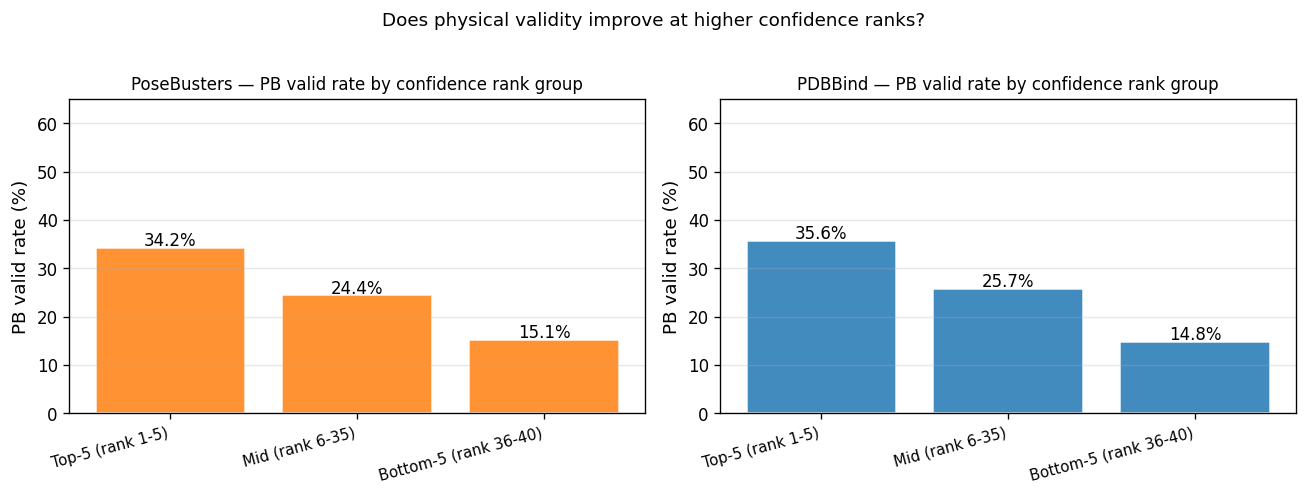

In [16]:
# ── Check failure rate at high-confidence (rank 1-5) vs low-confidence (rank 36-40) ──
#
# For each complex, does the confidence model preferentially pick poses that fail
# specific checks?  We compare failure rates in the top-5 vs bottom-5 ranks.

def failure_rate_by_rank_group(names, json_data, valid_arr, n_top=5, n_bot=5, n_samples=40):
    """Compare PB failure rate (1 − valid) at top-5 vs bottom-5 ranks."""
    top_valid = valid_arr[:, :n_top].mean()
    bot_valid = valid_arr[:, -n_bot:].mean()
    return {
        f'Top-{n_top} (rank 1-{n_top})':      top_valid,
        f'Mid (rank {n_top+1}-{n_samples-n_bot})': valid_arr[:, n_top:-n_bot].mean(),
        f'Bottom-{n_bot} (rank {n_samples-n_bot+1}-{n_samples})': bot_valid,
    }

groups_pb  = failure_rate_by_rank_group(pb_names,  pb_json,  valid_pb)
groups_pdb = failure_rate_by_rank_group(pdb_names, pdb_json, valid_pdb)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (ds_label, groups, color) in zip(axes, [
    ('PoseBusters', groups_pb,  'C1'),
    ('PDBBind',     groups_pdb, 'C0'),
]):
    labels = list(groups.keys())
    rates  = [v * 100 for v in groups.values()]  # valid rate
    bars = ax.bar(labels, rates, color=color, edgecolor='white', alpha=0.85)
    for bar, r in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{r:.1f}%', ha='center', fontsize=10)
    ax.set_ylabel('PB valid rate (%)', fontsize=11)
    ax.set_ylim(0, 65)
    ax.set_title(f'{ds_label} — PB valid rate by confidence rank group', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.suptitle('Does physical validity improve at higher confidence ranks?', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_validity_by_rank_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Valid Pose Count Distribution

How many physical poses does the score model actually produce per complex?  
A complex with 0 valid poses is a complete score-model failure. A complex with 30+ valid poses is a near-perfect generation problem where the confidence model just needs to pick the right one.

  PoseBusters (S=40): none valid poses: 37.0% of complexes
  PoseBusters (S=40): ≥1 valid poses: 55.7% of complexes
  PoseBusters (S=40): ≥5 valid poses: 42.0% of complexes
  PoseBusters (S=40): ≥10 valid poses: 32.5% of complexes

  PDBBind (S=40): none valid poses: 30.1% of complexes
  PDBBind (S=40): ≥1 valid poses: 60.6% of complexes
  PDBBind (S=40): ≥5 valid poses: 44.7% of complexes
  PDBBind (S=40): ≥10 valid poses: 32.9% of complexes



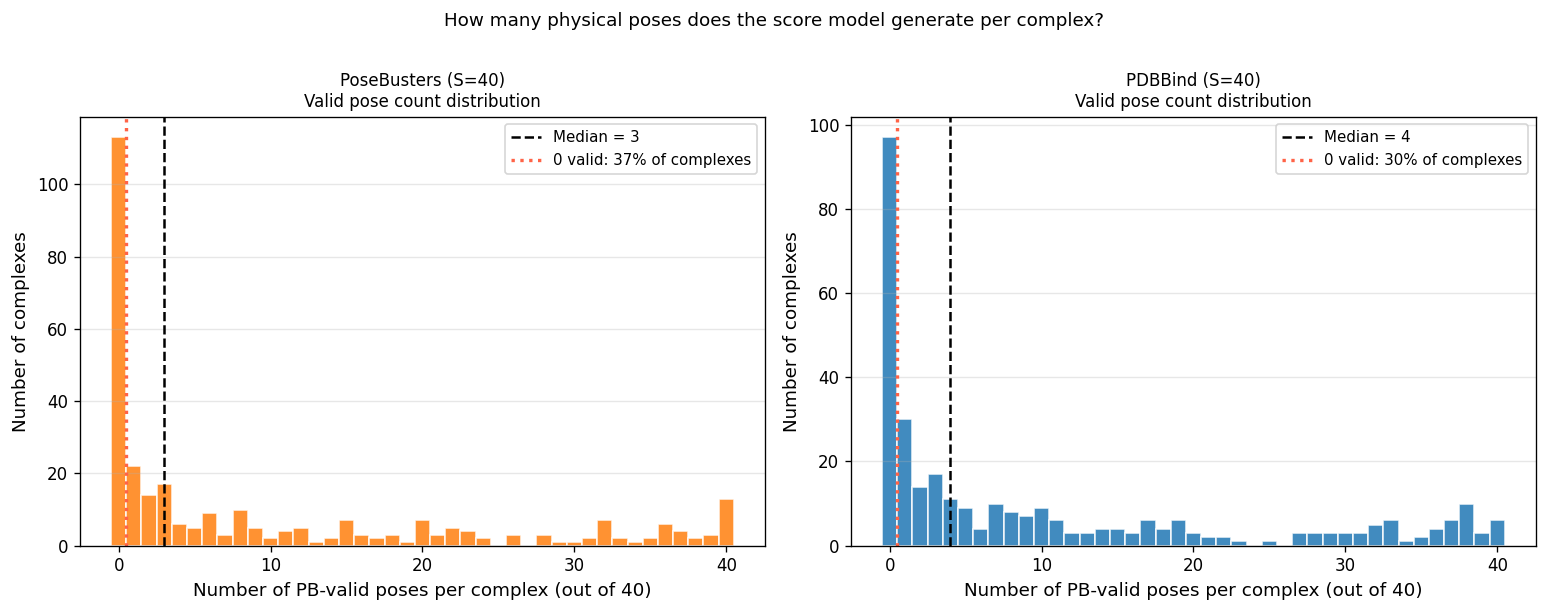

In [17]:
n_valid_pb  = valid_pb.sum(axis=1)   # (303,)
n_valid_pdb = valid_pdb.sum(axis=1)  # (322,)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ds_label, n_v, color) in zip(axes, [
    ('PoseBusters (S=40)', n_valid_pb,  'C1'),
    ('PDBBind (S=40)',     n_valid_pdb, 'C0'),
]):
    bins = np.arange(-0.5, S + 1.5, 1)
    ax.hist(n_v, bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.median(n_v), color='k', ls='--', lw=1.5,
               label=f'Median = {np.median(n_v):.0f}')
    ax.axvline(0.5, color='tomato', ls=':', lw=2,
               label=f'0 valid: {(n_v==0).mean()*100:.0f}% of complexes')

    # Annotate key thresholds
    for thr, name in [(0, 'none'), (1, '≥1'), (5, '≥5'), (10, '≥10')]:
        pct = (n_v > thr if thr > 0 else n_v == thr).mean() * 100
        print(f'  {ds_label}: {name} valid poses: {pct:.1f}% of complexes')

    ax.set_xlabel('Number of PB-valid poses per complex (out of 40)', fontsize=11)
    ax.set_ylabel('Number of complexes', fontsize=11)
    ax.set_title(f'{ds_label}\nValid pose count distribution', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    print()

plt.suptitle('How many physical poses does the score model generate per complex?', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_valid_count_dist.png', dpi=150, bbox_inches='tight')
plt.show()

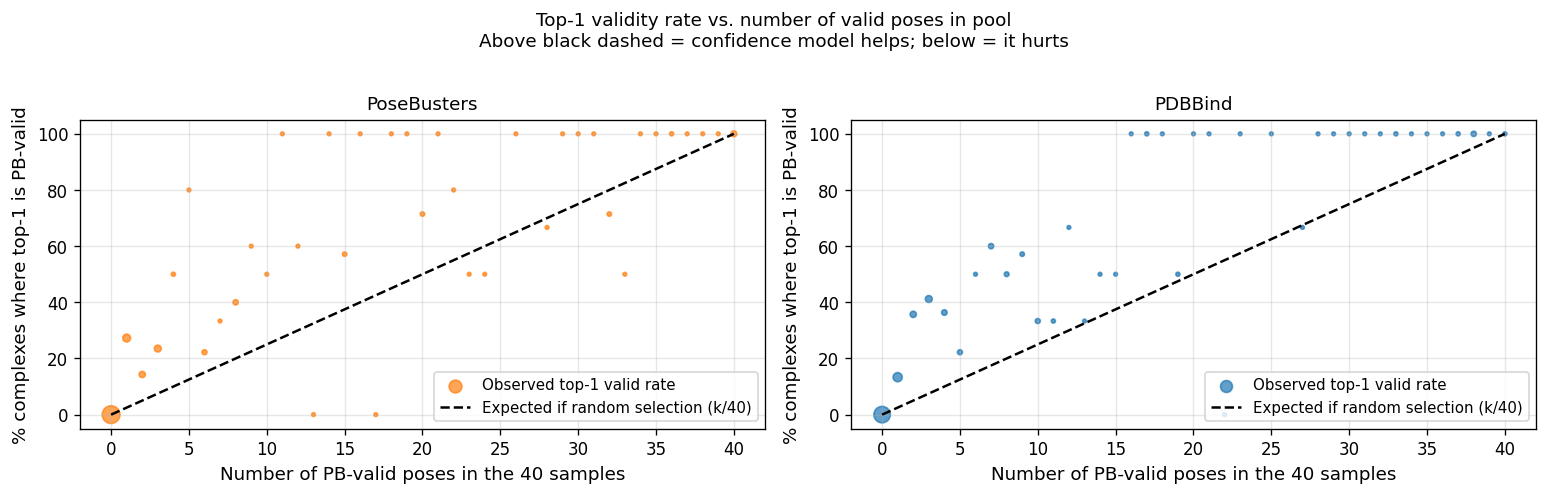

In [18]:
# ── Does having more valid poses correlate with the top-1 being valid? ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (ds_label, n_v, valid_r, color) in zip(axes, [
    ('PoseBusters', n_valid_pb,  valid_pb,  'C1'),
    ('PDBBind',     n_valid_pdb, valid_pdb, 'C0'),
]):
    # For each possible valid-count value, fraction where top-1 is valid
    counts = np.arange(0, S + 1)
    top1_valid_rate = []
    n_complexes     = []
    for c in counts:
        mask = n_v == c
        if mask.sum() == 0:
            top1_valid_rate.append(np.nan)
        else:
            top1_valid_rate.append(valid_r[mask, 0].mean())
        n_complexes.append(mask.sum())

    top1_valid_rate = np.array(top1_valid_rate)
    finite = np.isfinite(top1_valid_rate)

    # Expected rate if confidence model picks randomly: n_valid/S
    expected_rate = counts / S

    ax.scatter(counts[finite], top1_valid_rate[finite] * 100,
               s=[max(5, n_complexes[c]) for c in counts[finite]],
               color=color, alpha=0.7, label='Observed top-1 valid rate')
    ax.plot(counts, expected_rate * 100, 'k--', lw=1.5,
            label='Expected if random selection (k/40)')
    ax.set_xlabel('Number of PB-valid poses in the 40 samples', fontsize=11)
    ax.set_ylabel('% complexes where top-1 is PB-valid', fontsize=11)
    ax.set_title(f'{ds_label}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Top-1 validity rate vs. number of valid poses in pool\n'
             'Above black dashed = confidence model helps; below = it hurts', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_top1_validity_vs_pool_size.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. RMSD Gap — Accuracy Gain from Perfect PB Reranking

If we could perfectly identify valid poses and always pick the best valid one, how much accuracy would we gain versus taking rank-1?  
This gives an **upper bound on the benefit of PB-aware reranking**.

We also compare:
- **Raw top-1**: RMSD of highest-confidence pose (current DiffDock behaviour)
- **First valid**: RMSD of first (highest-confidence) PB-valid pose
- **Best valid**: RMSD of the single best PB-valid pose (oracle lower bound)

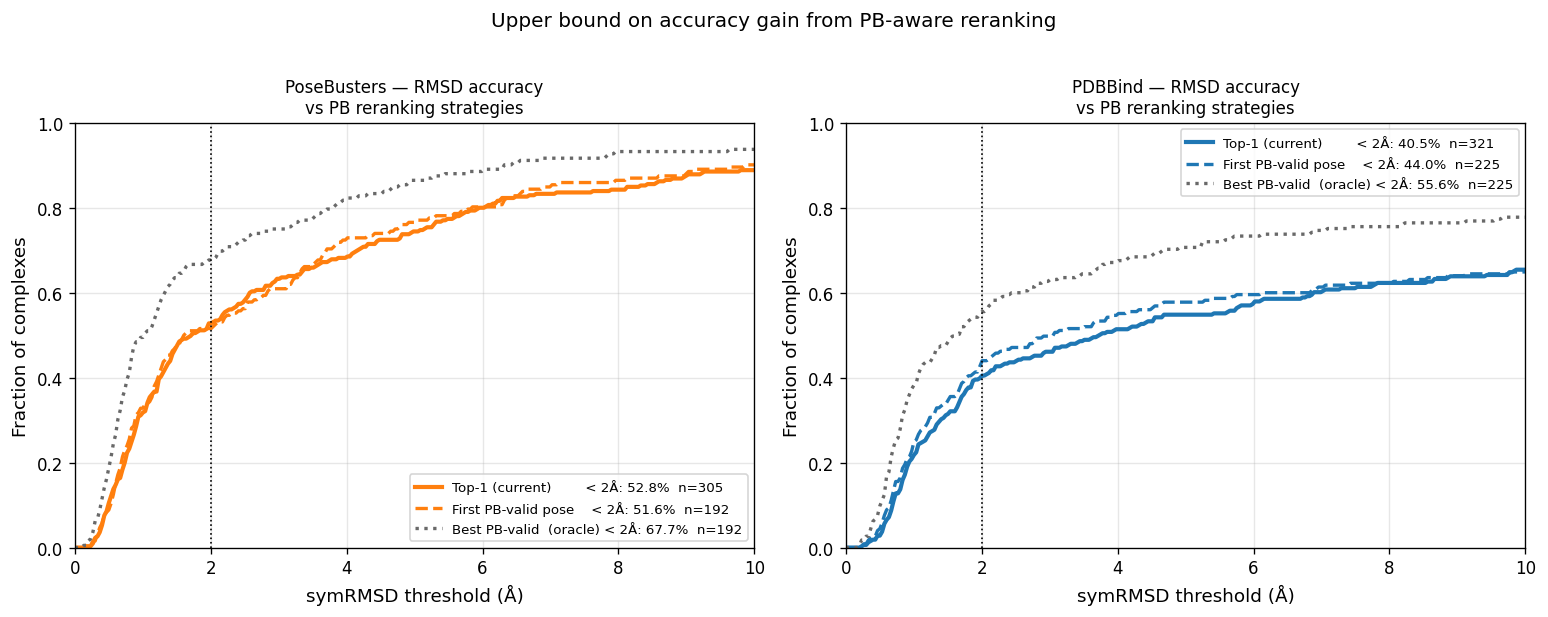

In [19]:
def rmsd_gap_analysis(rmsds_r, valid_r, top1_rmsd):
    """Compute RMSD for top-1, first valid, and best valid poses."""
    n = len(rmsds_r)
    rmsd_top1      = top1_rmsd.copy()
    rmsd_first_valid = np.full(n, np.nan)
    rmsd_best_valid  = np.full(n, np.nan)

    for i in range(n):
        valid_idx = np.where(valid_r[i])[0]
        if len(valid_idx) == 0:
            continue
        rmsd_first_valid[i] = rmsds_r[i, valid_idx[0]]
        rmsd_best_valid[i]  = np.nanmin(rmsds_r[i, valid_idx])

    return rmsd_top1, rmsd_first_valid, rmsd_best_valid

pb_t1,  pb_fv,  pb_bv  = rmsd_gap_analysis(rmsds_pb,       valid_pb,  top1_rmsd_pb)
pdb_t1, pdb_fv, pdb_bv = rmsd_gap_analysis(rmsds_ranked_pdb, valid_pdb, top1_rmsd_pdb)

thresholds = np.linspace(0, 10, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (ds_label, t1, fv, bv, color) in zip(axes, [
    ('PoseBusters', pb_t1,  pb_fv,  pb_bv,  'C1'),
    ('PDBBind',     pdb_t1, pdb_fv, pdb_bv, 'C0'),
]):
    valid_t1 = t1[np.isfinite(t1)]
    valid_fv = fv[np.isfinite(fv)]
    valid_bv = bv[np.isfinite(bv)]

    cdf_t1 = [(valid_t1 < thr).mean() for thr in thresholds]
    cdf_fv = [(valid_fv < thr).mean() for thr in thresholds]
    cdf_bv = [(valid_bv < thr).mean() for thr in thresholds]

    t2_t1 = (valid_t1 < 2).mean() * 100
    t2_fv = (valid_fv < 2).mean() * 100
    t2_bv = (valid_bv < 2).mean() * 100

    ax.plot(thresholds, cdf_t1, color=color,        lw=2.5,
            label=f'Top-1 (current)        < 2Å: {t2_t1:.1f}%  n={len(valid_t1)}')
    ax.plot(thresholds, cdf_fv, color=color,        lw=2,   ls='--',
            label=f'First PB-valid pose    < 2Å: {t2_fv:.1f}%  n={len(valid_fv)}')
    ax.plot(thresholds, cdf_bv, color='dimgrey',    lw=2,   ls=':',
            label=f'Best PB-valid  (oracle) < 2Å: {t2_bv:.1f}%  n={len(valid_bv)}')
    ax.axvline(2, color='k', ls=':', lw=1)
    ax.set_xlim(0, 10); ax.set_ylim(0, 1)
    ax.set_xlabel('symRMSD threshold (Å)', fontsize=11)
    ax.set_ylabel('Fraction of complexes', fontsize=11)
    ax.set_title(f'{ds_label} — RMSD accuracy\nvs PB reranking strategies', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Upper bound on accuracy gain from PB-aware reranking', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_rmsd_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Table

Consolidated numbers for both test sets.

In [20]:
rows = []
for label, n_c, valid_r, t1_rmsd, fv_rmsd, bv_rmsd, conf_r, A, B, C in [
    ('PoseBusters', N_PB,  valid_pb,  top1_rmsd_pb,  pb_fv,  pb_bv,  conf_ranked_pb,  A_pb,  B_pb,  C_pb),
    ('PDBBind',     N_PDB, valid_pdb, top1_rmsd_pdb, pdb_fv, pdb_bv, conf_ranked_pdb, A_pdb, B_pdb, C_pdb),
]:
    n_S = valid_r.shape[1]
    fin_t1  = t1_rmsd[np.isfinite(t1_rmsd)]
    fin_fv  = fv_rmsd[np.isfinite(fv_rmsd)]
    fin_bv  = bv_rmsd[np.isfinite(bv_rmsd)]
    c_all   = conf_r.ravel(); c_all = c_all[np.isfinite(c_all)]
    v_all   = valid_r.ravel()[np.isfinite(conf_r.ravel())]
    rho, p_rho = stats.spearmanr(c_all, v_all.astype(float))
    rows.append({
        'Dataset': label,
        'Complexes': n_c,
        'Samples/complex': n_S,
        'PB valid rate (all)': f"{valid_r.mean()*100:.1f}%",
        'Top-1 valid (Cat A)': f"{A.mean()*100:.1f}%",
        'Conf fail (Cat B)': f"{B.mean()*100:.1f}%",
        'Score fail (Cat C)': f"{C.mean()*100:.1f}%",
        '≥1 valid pose': f"{valid_r.any(axis=1).mean()*100:.1f}%",
        'Top-1 RMSD<2Å': f"{(fin_t1<2).mean()*100:.1f}%",
        'FirstValid RMSD<2Å': f"{(fin_fv<2).mean()*100:.1f}%",
        'BestValid RMSD<2Å': f"{(fin_bv<2).mean()*100:.1f}%",
        'Spearman ρ (conf vs valid)': f"{rho:+.3f}",
        'p-value': f"{p_rho:.2e}",
    })

df_summary = pd.DataFrame(rows).set_index('Dataset').T
print(df_summary.to_string())

Dataset                    PoseBusters   PDBBind
Complexes                          305       322
Samples/complex                     40        40
PB valid rate (all)              24.4%     25.6%
Top-1 valid (Cat A)              36.4%     40.4%
Conf fail (Cat B)                26.6%     29.5%
Score fail (Cat C)               37.0%     30.1%
≥1 valid pose                    63.0%     69.9%
Top-1 RMSD<2Å                    52.8%     40.5%
FirstValid RMSD<2Å               51.6%     44.0%
BestValid RMSD<2Å                67.7%     55.6%
Spearman ρ (conf vs valid)      +0.478    +0.488
p-value                       0.00e+00  0.00e+00


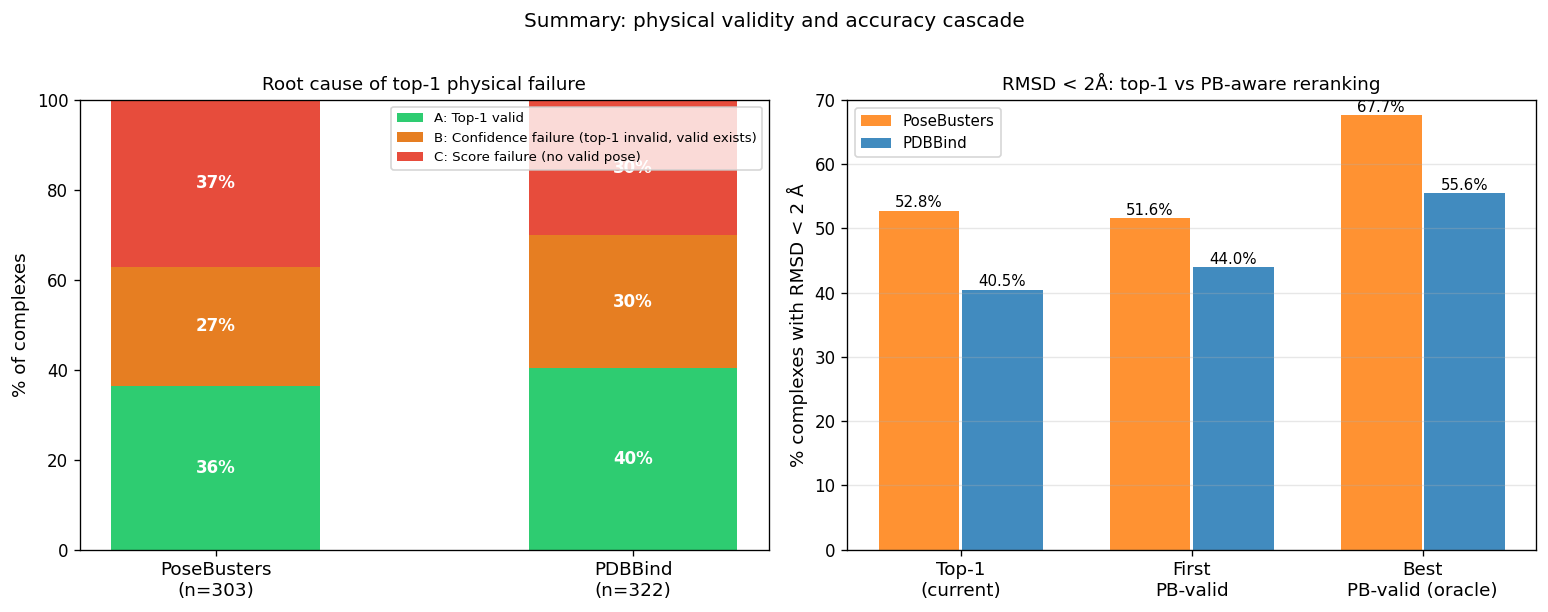

In [21]:
# ── Two-panel summary: category breakdown + RMSD accuracy cascade ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: stacked bar of categories for both test sets
ax = axes[0]
ds_names = ['PoseBusters\n(n=303)', 'PDBBind\n(n=322)']
cat_A_pcts = [A_pb.mean()*100, A_pdb.mean()*100]
cat_B_pcts = [B_pb.mean()*100, B_pdb.mean()*100]
cat_C_pcts = [C_pb.mean()*100, C_pdb.mean()*100]

x = np.arange(len(ds_names))
w = 0.5
b1 = ax.bar(x, cat_A_pcts, w, label='A: Top-1 valid',          color=COLORS['A'])
b2 = ax.bar(x, cat_B_pcts, w, bottom=cat_A_pcts,               color=COLORS['B'],
            label='B: Confidence failure (top-1 invalid, valid exists)')
b3 = ax.bar(x, cat_C_pcts, w,
            bottom=[a+b for a, b in zip(cat_A_pcts, cat_B_pcts)], color=COLORS['C'],
            label='C: Score failure (no valid pose)')

for bars, pcts in [(b1, cat_A_pcts), (b2, cat_B_pcts), (b3, cat_C_pcts)]:
    for bar, p in zip(bars, pcts):
        if p > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    f'{p:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(ds_names, fontsize=11)
ax.set_ylabel('% of complexes', fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Root cause of top-1 physical failure', fontsize=11)

# Right: RMSD < 2Å cascade for both test sets
ax2 = axes[1]
categories = ['Top-1\n(current)', 'First\nPB-valid', 'Best\nPB-valid (oracle)']

for ds_label, vals, color in [
    ('PoseBusters', [
        (top1_rmsd_pb[np.isfinite(top1_rmsd_pb)] < 2).mean()*100,
        (pb_fv[np.isfinite(pb_fv)] < 2).mean()*100,
        (pb_bv[np.isfinite(pb_bv)] < 2).mean()*100,
    ], 'C1'),
    ('PDBBind', [
        (top1_rmsd_pdb[np.isfinite(top1_rmsd_pdb)] < 2).mean()*100,
        (pdb_fv[np.isfinite(pdb_fv)] < 2).mean()*100,
        (pdb_bv[np.isfinite(pdb_bv)] < 2).mean()*100,
    ], 'C0'),
]:
    x = np.arange(len(categories))
    offset = -0.18 if ds_label == 'PoseBusters' else 0.18
    bars = ax2.bar(x + offset, vals, 0.35, label=ds_label, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=9)

ax2.set_xticks(np.arange(len(categories)))
ax2.set_xticklabels(categories, fontsize=11)
ax2.set_ylabel('% complexes with RMSD < 2 Å', fontsize=11)
ax2.set_ylim(0, 70)
ax2.set_title('RMSD < 2Å: top-1 vs PB-aware reranking', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Summary: physical validity and accuracy cascade', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_summary_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Ranking Strategy Comparison — Accuracy & SigmaDock Mixed Score

Compares five selection strategies on the PoseBusters test set:

| Strategy | Rule |
|---|---|
| **DiffDock top-1** | Highest DiffDock confidence score — current behaviour |
| **Gnina top-1** | Most negative Vinardo affinity (pure force-field) |
| **Mixed score top-1** | SigmaDock: `s = −affinity × p^β`, β=4 — validity-penalised affinity |
| **PB-filtered top-1** | Highest-confidence pose passing all 5 PB checks |
| **Oracle (best-of-40)** | Best RMSD among all 40 poses — hard upper bound |

The SigmaDock mixed score multiplies the Vinardo binding affinity by the average of 5 stereochemical PoseBusters checks raised to the power β=4. This heavily penalises poses that fail physical checks (p < 1), so invalid poses are pushed down the ranking even if they have strong raw affinity.

Data: `rescoring_vinardo.json` and `pb_checks.json` per complex under `pb_evaluate_v2_merged/` (produced by `gnina_rescore_poses.py` and `pb_check_poses.py`, both indexed in DiffDock confidence-rank order).

In [22]:
# ── Load affinity and PB-p score arrays for all PB complexes ─────────────────
#
# rmsds.npy is in generation order; confidences.npy is also generation order.
# affinity/p_score JSONs are keyed by "rank1"..."rank40" (DiffDock confidence
# rank order). We must sort rmsds_pb into rank order to align them.
#
# valid_pb (from pb_json valid_ranks) is already in rank order.

BETA = 4  # SigmaDock penalty exponent

# ── Build rank-ordered RMSD array ─────────────────────────────────────────────
conf_gen_pb   = np.load(f'{PB_METRICS}/confidences.npy')   # generation order
conf_gen_masked = np.where(conf_gen_pb == -1000, -np.inf, conf_gen_pb.astype(float))
sort_orders_pb  = np.argsort(-conf_gen_masked, axis=1)      # descending confidence
rmsds_ranked_pb = rmsds_pb[np.arange(N_PB)[:, None], sort_orders_pb]

# Sanity: col 0 should now match top1_rmsd_pb
assert np.allclose(rmsds_ranked_pb[:, 0], top1_rmsd_pb, atol=1e-4), \
    "Rank-ordering failed — rmsds_ranked_pb[:,0] ≠ top1_rmsd_pb"
print(f'rmsds_ranked_pb sanity check passed: col-0 accuracy = {(rmsds_ranked_pb[:,0]<2).mean()*100:.1f}%')

affinity = np.full((N_PB, S), np.nan)   # Vinardo kcal/mol (negative = better binding)
p_score  = np.full((N_PB, S), np.nan)   # average of 5 PB check booleans in [0, 1]

missing_affinity = 0
missing_pb_checks = 0

for i, name in enumerate(pb_names):
    cdir = Path(PB_RESULTS_DIR) / name

    # Vinardo affinity
    aff_path = cdir / 'rescoring_vinardo.json'
    if aff_path.exists():
        aff_data = json.loads(aff_path.read_text())
        for rank_idx in range(S):
            key = f'rank{rank_idx + 1}'
            if key in aff_data and aff_data[key].get('affinity') is not None:
                affinity[i, rank_idx] = aff_data[key]['affinity']
    else:
        missing_affinity += 1

    # PB stereochemical p score
    pb_path = cdir / 'pb_checks.json'
    if pb_path.exists():
        pb_data = json.loads(pb_path.read_text())
        for rank_idx in range(S):
            key = f'rank{rank_idx + 1}'
            if key in pb_data and pb_data[key].get('p') is not None:
                p_score[i, rank_idx] = pb_data[key]['p']
    else:
        missing_pb_checks += 1

# Mixed score: s_i = -affinity_i * p_i^beta   (higher = better)
mixed = -affinity * (p_score ** BETA)

n_aff_valid  = np.isfinite(affinity).all(axis=1).sum()
n_pb_valid   = np.isfinite(p_score).all(axis=1).sum()
n_both_valid = (np.isfinite(affinity) & np.isfinite(p_score)).all(axis=1).sum()

print(f'Missing rescoring_vinardo.json: {missing_affinity} complexes')
print(f'Missing pb_checks.json:         {missing_pb_checks} complexes')
print(f'Full affinity coverage (all 40 ranks): {n_aff_valid} complexes')
print(f'Full pb_checks coverage (all 40 ranks): {n_pb_valid} complexes')
print(f'Both available:                         {n_both_valid} complexes')
print(f'\nAffinity range: {np.nanmin(affinity):.2f} to {np.nanmax(affinity):.2f} kcal/mol')
print(f'p-score range:  {np.nanmin(p_score):.2f} to {np.nanmax(p_score):.2f}')
print(f'Mixed score range: {np.nanmin(mixed):.2f} to {np.nanmax(mixed):.2f}')


rmsds_ranked_pb sanity check passed: col-0 accuracy = 52.8%
Missing rescoring_vinardo.json: 0 complexes
Missing pb_checks.json:         0 complexes
Full affinity coverage (all 40 ranks): 287 complexes
Full pb_checks coverage (all 40 ranks): 304 complexes
Both available:                         287 complexes

Affinity range: -16.60 to 567.61 kcal/mol
p-score range:  0.00 to 1.00
Mixed score range: -274.99 to 16.60


In [23]:
# ── Build per-complex top-1 RMSD for each ranking strategy ───────────────────
#
# All score arrays (affinity, mixed) are in rank order, matching rmsds_ranked_pb.
# valid_pb is also in rank order. So we index rmsds_ranked_pb with rank indices.

has_affinity = np.isfinite(affinity).any(axis=1)
has_pb       = np.isfinite(p_score).any(axis=1)
has_both     = has_affinity & has_pb

def pick_top1_rmsd(score_matrix, rmsds, maximize=True, mask=None):
    """Select the pose with the best score per complex and return its RMSD."""
    n = len(rmsds)
    result = np.full(n, np.nan)
    for i in range(n):
        row = score_matrix[i]
        finite = np.isfinite(row)
        if not finite.any():
            continue
        if mask is not None and not mask[i]:
            continue
        idx = np.nanargmax(row) if maximize else np.nanargmin(row)
        result[i] = rmsds[i, idx]
    return result

# PB-filter: first rank where valid_pb is True (valid_pb and rmsds_ranked_pb share rank order)
rmsd_pb_filter = np.full(N_PB, np.nan)
for i in range(N_PB):
    valid_idx = np.where(valid_pb[i])[0]
    if len(valid_idx) > 0:
        rmsd_pb_filter[i] = rmsds_ranked_pb[i, valid_idx[0]]

rmsd_diffdock  = rmsds_ranked_pb[:, 0].copy()               # DiffDock conf top-1
rmsd_gnina     = pick_top1_rmsd(affinity,   rmsds_ranked_pb, maximize=False)  # min affinity
rmsd_mixed     = pick_top1_rmsd(mixed,      rmsds_ranked_pb, maximize=True)   # max mixed score
rmsd_oracle    = np.nanmin(rmsds_ranked_pb, axis=1)          # best of 40

strategies = [
    ('DiffDock top-1\n(confidence)',    rmsd_diffdock,  'C1',       None),
    ('Gnina top-1\n(Vinardo affinity)', rmsd_gnina,     '#8e44ad',  has_affinity),
    ('Mixed score top-1\n(SigmaDock)', rmsd_mixed,      '#e67e22',  has_both),
    ('PB-filtered top-1\n(first valid)', rmsd_pb_filter,'#27ae60',  None),
    ('Oracle\n(best-of-40)',            rmsd_oracle,    '#7f8c8d',   None),
]

# NaN < 2 → False in numpy, so NaN poses count as failures (consistent denominator)
print(f'{"Strategy":<32}  {"RMSD<2Å (all n)":>16}  {"n":>5}')
print('-' * 58)
for label, rmsd, color, mask in strategies:
    x = rmsd if mask is None else rmsd[mask]
    acc = (x < 2).sum() / len(x) * 100
    print(f'{label.replace(chr(10), " "):<32}  {acc:>15.1f}%  {len(x):>5}')

print()
n_pb_filter_valid = np.isfinite(rmsd_pb_filter).sum()
pb_cond = (rmsd_pb_filter[np.isfinite(rmsd_pb_filter)] < 2).mean() * 100
print(f'PB-filter conditional accuracy (only {n_pb_filter_valid} complexes with ≥1 valid pose): {pb_cond:.1f}%')


Strategy                           RMSD<2Å (all n)      n
----------------------------------------------------------
DiffDock top-1 (confidence)                  52.8%    305
Gnina top-1 (Vinardo affinity)               49.2%    305
Mixed score top-1 (SigmaDock)                47.9%    305
PB-filtered top-1 (first valid)              38.0%    305
Oracle (best-of-40)                          61.6%    305

PB-filter conditional accuracy (only 192 complexes with ≥1 valid pose): 60.4%


Strategy                 RMSD<2Å    RMSD<2Å & PB-valid     PB-valid among acc.
------------------------------------------------------------------------------
DiffDock conf              52.8%                 27.2%                   51.6%
Gnina Vinardo              49.2%                 31.8%                   64.7%
SigmaDock mixed            47.9%                 36.1%                   75.3%
Oracle best-of-40          61.6%                 29.5%                   47.9%


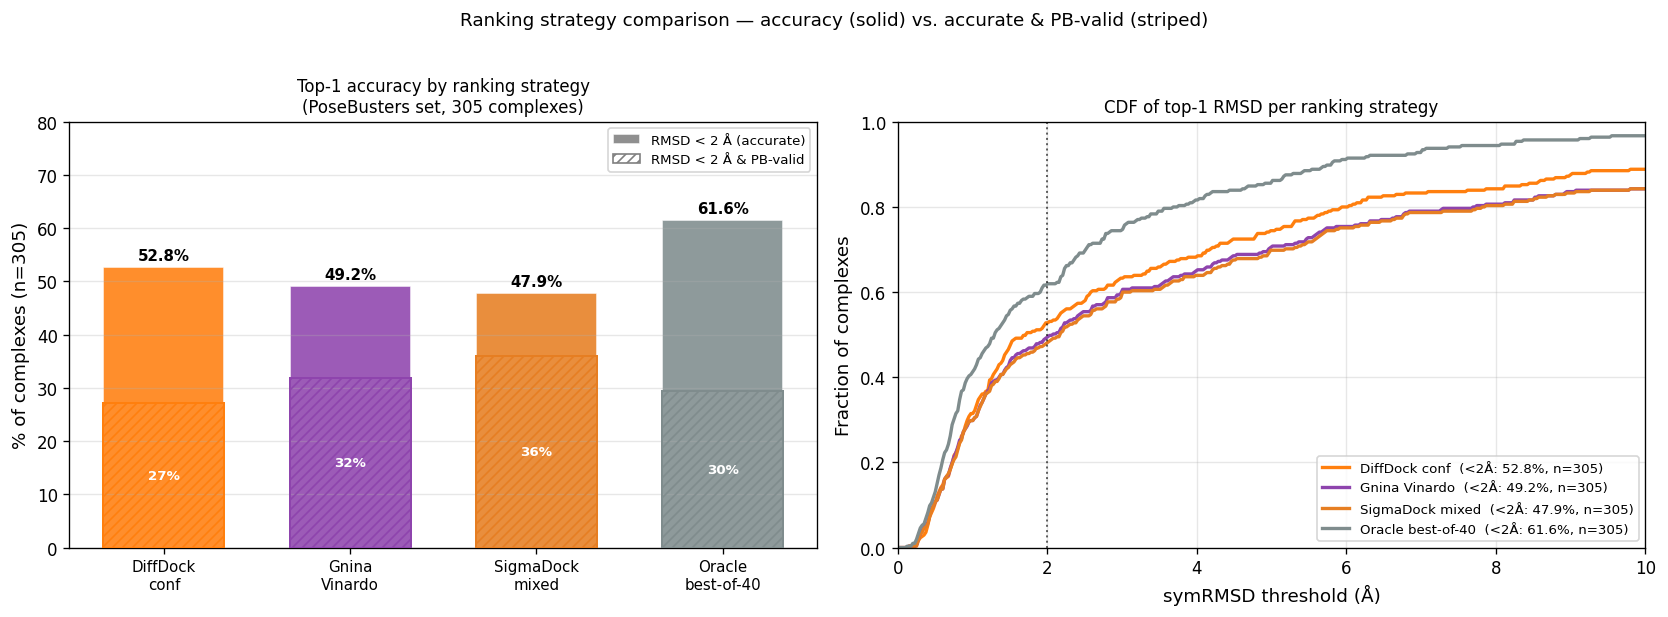

In [24]:
# ── Section 11 visualisation: bar chart + CDF curves ─────────────────────────
#
# Each bar shows two quantities:
#   Solid   = RMSD < 2Å accuracy (any selected pose, PB-valid or not)
#   Striped = RMSD < 2Å AND PB-valid — always a subset of the solid bar
#
# The striped height ≤ solid height by construction: requiring physical validity
# can only reduce accuracy, never increase it.
# PB-filtered top-1 is merged into DiffDock: the stripe on DiffDock shows exactly
# how much of its accuracy survives the PB filter.

thresholds = np.linspace(0, 10, 400)

# ── Strategies: DiffDock, Gnina, SigmaDock mixed, Oracle (no PB-filtered) ────
strategies_viz = [(l, r, c, m) for l, r, c, m in strategies if 'PB-filter' not in l]
labels_short   = ['DiffDock\nconf', 'Gnina\nVinardo', 'SigmaDock\nmixed', 'Oracle\nbest-of-40']

# ── Selected rank index per complex for each strategy ─────────────────────────
diffdock_sel = np.zeros(N_PB, dtype=int)                                 # always rank 0
gnina_sel    = np.array([np.nanargmin(affinity[i]) for i in range(N_PB)])
mixed_sel    = np.array([np.nanargmax(mixed[i])    for i in range(N_PB)])
oracle_sel   = np.nanargmin(rmsds_ranked_pb, axis=1)

sel_indices = [diffdock_sel, gnina_sel, mixed_sel, oracle_sel]

# ── Accuracy and joint (accurate AND PB-valid) rate for each strategy ─────────
acc_vals_viz      = []
acc_pb_valid_vals = []
colors_viz        = []

for (label, rmsd, color, mask), sel in zip(strategies_viz, sel_indices):
    sel_rmsd  = rmsds_ranked_pb[np.arange(N_PB), sel]   # RMSD at selected rank
    sel_valid = valid_pb[np.arange(N_PB), sel]            # PB validity at selected rank
    acc    = (sel_rmsd < 2).mean() * 100
    acc_pb = ((sel_rmsd < 2) & sel_valid).mean() * 100   # joint: accurate AND PB-valid
    acc_vals_viz.append(acc)
    acc_pb_valid_vals.append(acc_pb)
    colors_viz.append(color)

print(f'{"Strategy":<22}  {"RMSD<2Å":>8}  {"RMSD<2Å & PB-valid":>20}  {"PB-valid among acc.":>22}')
print('-' * 78)
for lbl, acc, acc_pb in zip(labels_short, acc_vals_viz, acc_pb_valid_vals):
    frac = acc_pb / acc * 100 if acc > 0 else 0
    print(f'{lbl.replace(chr(10)," "):<22}  {acc:>7.1f}%  {acc_pb:>19.1f}%  {frac:>21.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: bar chart ───────────────────────────────────────────────────────────
ax = axes[0]
x_pos = np.arange(len(strategies_viz))

for xi, color, acc, acc_pb, short in zip(x_pos, colors_viz, acc_vals_viz, acc_pb_valid_vals, labels_short):
    # Solid bar: RMSD < 2Å accuracy
    ax.bar(xi, acc, color=color, edgecolor='white', alpha=0.88, width=0.65)

    # Striped overlay: RMSD < 2Å AND PB-valid (always ≤ acc)
    ax.bar(xi, acc_pb, fill=False, edgecolor=color, hatch='////',
           linewidth=1.2, width=0.65, zorder=3)

    # Accuracy annotation above bar
    ax.text(xi, acc + 0.7, f'{acc:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
    # Joint rate annotation inside the striped region
    if acc_pb > 5:
        ax.text(xi, acc_pb / 2, f'{acc_pb:.0f}%', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_short, fontsize=9)
ax.set_ylabel('% of complexes (n=305)', fontsize=11)
ax.set_ylim(0, 80)
ax.set_title('Top-1 accuracy by ranking strategy\n(PoseBusters set, 305 complexes)', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='grey', edgecolor='white', alpha=0.88, label='RMSD < 2 Å (accurate)'),
    Patch(facecolor='none', edgecolor='grey', hatch='////', label='RMSD < 2 Å & PB-valid'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# ── Right: CDF curves ─────────────────────────────────────────────────────────
ax2 = axes[1]
for (label, rmsd, color, mask), short in zip(strategies_viz, labels_short):
    x = rmsd if mask is None else rmsd[mask]
    n_total = len(x)
    cdf = [(x < t).sum() / n_total for t in thresholds]
    acc2 = (x < 2).sum() / n_total * 100
    ax2.plot(thresholds, cdf, color=color, lw=2,
             label=f'{short.replace(chr(10), " ")}  (<2Å: {acc2:.1f}%, n={n_total})')

ax2.axvline(2, color='k', ls=':', lw=1.2, alpha=0.6)
ax2.set_xlabel('symRMSD threshold (Å)', fontsize=11)
ax2.set_ylabel('Fraction of complexes', fontsize=11)
ax2.set_title('CDF of top-1 RMSD per ranking strategy', fontsize=10)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('Ranking strategy comparison — accuracy (solid) vs. accurate & PB-valid (striped)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_ranking_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
